# Gaming Toxicity Detection

**Authors:** Beibarys Nyussupov, Ruby Ngo, Paola Calle, Jett Forward


In [58]:
# libraries 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
import html as html_lib
from nltk.tokenize import TweetTokenizer


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import html as html_lib
from pathlib import Path
import os 
import spacy
nlp = spacy.load("en_core_web_sm")

# reproducibility
seed = 7524
np.random.seed(seed)

# project root (notebooks/gaming/ -> notebooks/ -> project root)
PROJECT_ROOT = Path().resolve().parent.parent

In [59]:
# data directories
DATA_DIR_WOT  = PROJECT_ROOT / "data/processed_data/wot/"
DATA_DIR_DOTA = PROJECT_ROOT / "data/processed_data/dota/"

## World of Tanks

In [60]:
# read parquet file
wot = pd.read_parquet(DATA_DIR_WOT / "wot.parquet")
# check 
print(f"Dataset shape: {wot.shape}")
print(f"Dataset first 5 rows:\n{wot.head(5)}\n")
print(f"Dataset info:")
wot.info()


Dataset shape: (49097, 3)
Dataset first 5 rows:
   index                        message  label
0  30702                        no rush    0.0
1  18607  whatever ... watch the replay    0.0
2  32901                        useless    1.0
3  25964                      3 gunmark    0.0
4  28643                            lol    0.0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49097 entries, 0 to 49096
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    49097 non-null  int64  
 1   message  49097 non-null  object 
 2   label    49097 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


### Exploratory Data Analysis (EDA)

| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

#### Duplicates

In [61]:
# look at dataset with duplicates 
wot_dup = wot[wot.duplicated(subset="message", keep=False)].sort_values("message")
# look at some examples
wot_dup.head(10)

,index,message,label
43053,40582,!,0.0
39349,6872,!,0.0
14047,31613,!,0.0
27307,39948,!!!!,0.0
33015,32907,!!!!,0.0
45018,1278,!!!!,0.0
11413,8848,#,0.0
9343,16596,#,0.0
31405,41473,#ERROR!,0.0
48538,20568,#ERROR!,0.0


In [62]:
# top 100 duplicated messages
wot_dup["message"].value_counts(ascending=False).head(100)

message
gg                   3188
lol                   458
nice                  396
gj                    315
cap                   190
                     ... 
Im Spotted at D5!      26
Im Spotted at G2!      26
ggg                    26
??                     26
leo                    26
Name: count, Length: 100, dtype: int64

Most of these duplicates are useful and important data to train or models for detecting toxicity. We need to check for same messages but different labels.

In [63]:
# Look for duplicates with same messages but different labels
conflicts = wot.groupby("message")["label"].nunique()
conflicts = conflicts[conflicts > 1]

print(f"Messages with conflicting labels: {len(conflicts)}")
conflict_rows = wot[wot["message"].isin(conflicts.index)].sort_values("message")

# Check how large is the proportion of conflicting duplicates
conflict_pct = len(conflict_rows) / len(wot) * 100
print(f"Proportion of messages with conflicting labels: {conflict_pct:.2f}%")
print(f"Number of messages with conflicting labels: {len(conflict_rows)}")

Messages with conflicting labels: 267
Proportion of messages with conflicting labels: 13.53%
Number of messages with conflicting labels: 6645


In [64]:
# check conflicting rows 
conflict_rows 

,index,message,label
6938,20569,#ERROR!,0.0
45667,36452,#ERROR!,0.0
40892,36443,#ERROR!,0.0
13382,27630,#ERROR!,0.0
33135,22663,#ERROR!,0.0
...,...,...,...
20833,13279,you lost,1.0
20931,44232,you lost,2.0
45197,17220,you lost,0.0
27706,9108,you wanna loose that right?,2.0


These messages can not be used for analysis, since it is a problem of `annotation`. Using them will be equal to guessing. Duplicated rows account for 14% of the data, which is a huge loss but we can not use that.

In [65]:
# drop conflicting messages
wot = wot[~wot["message"].isin(conflicts.index)].reset_index(drop=True)
print(wot.shape)

(42452, 3)


In [66]:
# check for any conflicting duplicates remaining
conflicts_after = wot.groupby("message")["label"].nunique()
conflicts_after = conflicts_after[conflicts_after > 1]
print(f"Conflicting messages remaining after removal: {len(conflicts_after)}")

Conflicting messages remaining after removal: 0


#### Class distribution

In [67]:
# Class balance check
print(f"Class distribution:\n{wot['label'].value_counts()}\n")
print(f"Class distribution (normalized):\n{wot['label'].value_counts(normalize=True)}")

Class distribution:
label
0.0    34046
1.0     6278
2.0     1805
3.0      239
4.0       61
5.0       23
Name: count, dtype: int64

Class distribution (normalized):
label
0.0    0.801988
1.0    0.147885
2.0    0.042519
3.0    0.005630
4.0    0.001437
5.0    0.000542
Name: proportion, dtype: float64


C:\Users\nyuss\AppData\Local\Temp\ipykernel_31400\3772814331.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\nyuss\AppData\Local\Temp\ipykernel_31400\3772814331.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


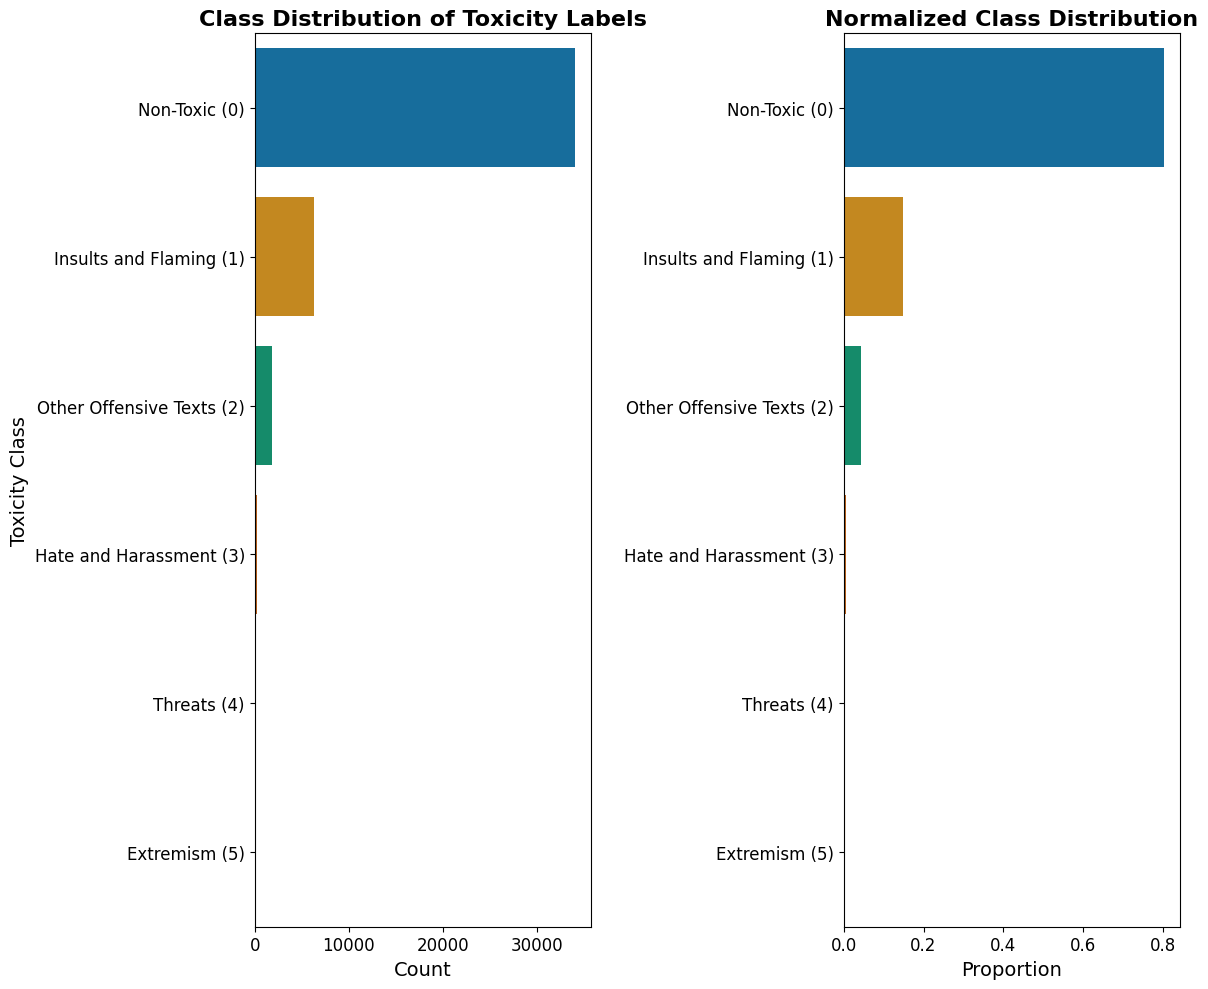

In [68]:
# Class balance plot + normalized class balance plot side by side

# class order and readable labels
class_order = [0, 1, 2, 3, 4, 5]
class_labels = [
    "Non-Toxic (0)",
    "Insults and Flaming (1)",
    "Other Offensive Texts (2)",
    "Hate and Harassment (3)",
    "Threats (4)",
    "Extremism (5)"
]

# map numeric labels to readable names
label_map = dict(zip(class_order, class_labels))
wot["label_name"] = wot["label"].map(label_map)

# normalized proportions
class_props = (
    wot["label"]
    .value_counts(normalize=True)
    .reindex(class_order)
)

# figure
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# raw counts plot
sns.countplot(
    y="label_name",
    data=wot,
    order=class_labels,
    palette="colorblind",
    ax=axes[0]
)

# aesthetics
# title 
axes[0].set_title("Class Distribution of Toxicity Labels", fontweight="bold", fontsize=16)

# axis labels and ticks
axes[0].set_xlabel("Count", fontsize=14)
axes[0].set_ylabel("Toxicity Class", fontsize=14)

axes[0].tick_params(axis="y", labelsize=12)
axes[0].tick_params(axis="x", labelsize=12)


# normalized distribution
sns.barplot(
    x=class_props.values,
    y=class_labels,
    palette="colorblind",
    ax=axes[1]
)

# aesthetics 
axes[1].set_title("Normalized Class Distribution", fontweight="bold", fontsize=16)

# axis labels and ticks 
axes[1].set_xlabel("Proportion", fontsize=14)

axes[1].tick_params(axis="y", labelsize=12)
axes[1].tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.show()

That gives us the idea that the class proportions are very imbalanced. We might experiment with binary vs multiclass classification later because of that. We could also merge minority labels to make it easier for model to learn data signals.

#### Non-English Messages (verification)

In [69]:
import re

NON_LATIN_SCRIPT = re.compile(
    r"[\u0400-\u04FF"   # Cyrillic
    r"\u4E00-\u9FFF"    # CJK unified ideographs
    r"\u3400-\u4DBF"    # CJK extension A
    r"\uF900-\uFAFF"    # CJK compatibility ideographs
    r"\u0600-\u06FF"    # Arabic
    r"\u0590-\u05FF"    # Hebrew
    r"\u3040-\u30FF"    # Japanese (Hiragana + Katakana)
    r"\uAC00-\uD7AF"    # Korean (Hangul syllables)
    r"\u1100-\u11FF"    # Korean (Hangul Jamo)
    r"\u0E00-\u0E7F"    # Thai
    r"\u0900-\u097F"    # Devanagari (Hindi)
    r"\u0980-\u09FF"    # Bengali
    r"\u0370-\u03FF"    # Greek
    r"\u10A0-\u10FF"    # Georgian
    r"\u0530-\u058F"    # Armenian
    r"\u1000-\u109F"    # Myanmar
    r"\u1780-\u17FF]"   # Khmer
)

non_english_count = wot["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False).sum()
print(f"Number of non-English script messages: {non_english_count}")
print(f"Percentage: {(non_english_count / len(wot)) * 100:.2f}%")

Number of non-English script messages: 0
Percentage: 0.00%


In [70]:
# check 
wot[wot["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False)]

,index,message,label,label_name


We successfully deleted everything in cleaning phase. 

#### Data Artifacts

In [71]:
# #ERROR! entries
error_count = wot["message"].str.contains(r"#ERROR!", regex=False, na=False).sum()
print(f"#ERROR! messages: {error_count}")

# HTML entities
html_mask = wot["message"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Messages with HTML entities: {html_mask.sum()}")
wot[html_mask][["message", "label"]].head(10)

#ERROR! messages: 0
Messages with HTML entities: 143


,message,label
22,&lt;#,0.0
111,&gt;bz,0.0
249,&lt;3,0.0
326,&lt;3,0.0
389,I've gotten all city maps today so I was like ...,0.0
475,"czech_mad_man[BD_CR] (Centurion 7/1), you‘re B...",0.0
1050,tog &amp; roll !! ladies,0.0
1374,&quot;_),0.0
2324,&lt;3,0.0
2374,&lt;3,0.0


In [72]:
# drop #ERROR! rows
wot = wot[~wot["message"].str.contains(r"#ERROR!", regex=False, na=False)].reset_index(drop=True)

# decode HTML entities inline
wot["message"] = wot["message"].apply(html_lib.unescape)

print(f"Shape after artifact removal: {wot.shape}")
# HTML entities
html_mask = wot["message"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Messages with HTML entities: {html_mask.sum()}")
wot[html_mask][["message", "label"]].head(10)

Shape after artifact removal: (42452, 4)
Messages with HTML entities: 0


,message,label


In [73]:
# check decoded messages 
wot.loc[[21, 119, 270, 353, 420, 1136, 
                 1497, 2526, 2581, 2961], ["message", "label"]]

,message,label
21,retard,1.0
119,u2,0.0
270,lolll,0.0
353,???,0.0
420,light,0.0
1136,ebr move bro move,0.0
1497,glhf,0.0
2526,from the back,0.0
2581,nice arty,0.0
2961,where is the support FV??,0.0


`#ERROR!` entries are spreadsheet import artifacts - they carry no linguistic content and would confuse any vectorizer. HTML entities like `&lt;` are encoding artifacts from the data collection pipeline; decoding them restores the original character so downstream tokenization sees real text instead of escape sequences.

#### Number of words per document

In [74]:
# splitting the dataset 

# features and target
X = wot["message"]
y = wot["label"]

# First split: 10% for final testing, 90% remains for training/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.10, random_state=7524, shuffle = True, stratify= y)

# datasets 
# train
train_df = pd.DataFrame({
    "message": X_train,
    "label": y_train
}).reset_index(drop=True)

# validation 
validation_df = pd.DataFrame({
    "message": X_val,
    "label": y_val
}).reset_index(drop=True)

# check shapes 
print(f"Train dataset shape:{train_df.shape}\n")
print(f"Validation dataset shape:{validation_df.shape}\n")

Train dataset shape:(38206, 2)

Validation dataset shape:(4246, 2)



In [75]:
# summary statistics of comments
print("Summary statistics of comment lengths:")

# create new column with comment world lengths
train_df["comment_length"] = train_df["message"].str.split().str.len()

# summary statistics 
train_describe = train_df["comment_length"].describe()
train_describe 

Summary statistics of comment lengths:


count    38206.000000
mean         3.257761
std          2.558094
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max         30.000000
Name: comment_length, dtype: float64

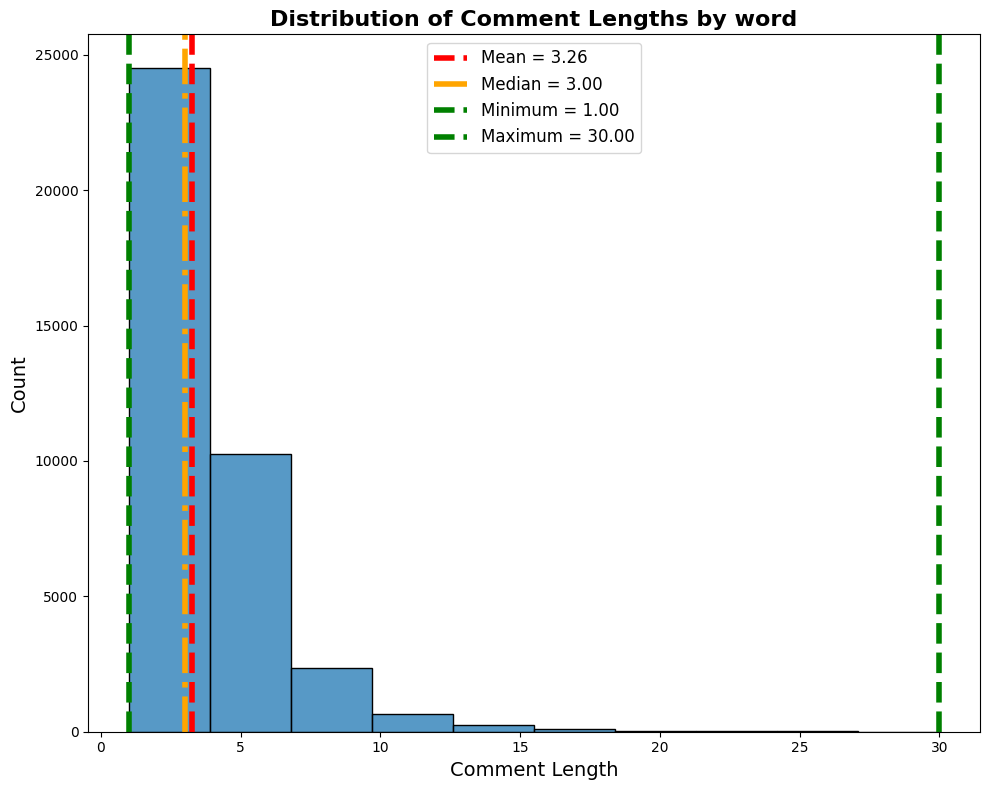

In [76]:
# distribution of world length 
# summary statistics
mean_len = train_df["comment_length"].mean()
median_len = train_df["comment_length"].median()
min_len = train_df["comment_length"].min()
max_len = train_df["comment_length"].max()

# plot
plt.figure(figsize=(10, 8))

# histogram plot
sns.histplot(
    train_df["comment_length"],
    bins=10,
    kde=False
)

# mean line
plt.axvline(
    mean_len,
    linestyle="--",
    linewidth=4,
    label=f"Mean = {mean_len:.2f}", 
    color = "red"
)

# median line
plt.axvline(
    median_len,
    linestyle="-.",
    linewidth=4,
    label=f"Median = {median_len:.2f}",
    color = "orange"
)

# min line 
plt.axvline(
    min_len,
    linestyle="--",
    linewidth=4,
    label=f"Minimum = {min_len:.2f}",
    color = "green"
)

# max line 
plt.axvline(
    max_len,
    linestyle="--",
    linewidth=4,
    label=f"Maximum = {max_len:.2f}",
    color = "green"
)

# title and labels
plt.title("Distribution of Comment Lengths by word", fontweight="bold", fontsize=16)

# xlabel
plt.xlabel("Comment Length", fontsize=14)

# ylabel
plt.ylabel("Count", fontsize=14)

# legend
plt.legend(fontsize=12)

# show the plot 
plt.tight_layout()
plt.show()

Messages are extremely short - median 3 words, max 30 in train data. Over 60% of messages are 1-3 words, confirming that gaming chat is reaction-driven rather than conversational. This justifies unigram + bigram TF-IDF: trigrams would overfit to specific full messages rather than capturing reusable toxic patterns.

In [77]:
# check messages 
# comments longer than or equal to the median top 10 words 
train_df[train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
0,Im Spotted at F5!,4,0.0
1,we are looseing time,4,0.0
2,must be player like you,5,0.0
3,idc of your dammage btw u are not in game for ...,14,1.0
4,maybe fck u,3,1.0
6,Im Spotted at G5! SOS!!!,5,0.0
7,Im Spotted at J2!,4,0.0
10,Im Spotted at H8!,4,0.0
12,60 cap points,3,0.0
13,gpo4b Ha JlT,3,0.0


In [78]:
# comments longer than or equal to the median bottom 10 words 
train_df[train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
38195,Im Spotted at B0!,4,0.0
38196,?? have b??g d??ck,4,1.0
38197,mongol team on hill,4,3.0
38198,go kill their arty,4,0.0
38199,Im Spotted at D7!,4,0.0
38200,is enoght t95?,3,0.0
38201,im stuck here,3,0.0
38202,how the f did I bounce one of my shots on the su,13,1.0
38203,no you will dround,4,0.0
38204,bisconte you have track you can move you know?,9,0.0


This confirms that if we use `trigrams`, the model potentially might overfit to longer sentences without actually capturing the context.

In [79]:
# comments shoterter than the median top 10 words 
train_df[train_df["comment_length"] < median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
5,ffs bots,2,1.0
8,oni use;esss,2,1.0
9,gg!!!,1,0.0
11,recgare,1,0.0
16,fhjng,1,0.0
17,*,1,0.0
19,10k,1,0.0
20,gah,1,0.0
21,hey friends,2,0.0
22,wtf,1,2.0


In [80]:
# comments shorter than the median bottom 10 words 
train_df[train_df["comment_length"] < median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
38174,both,1,0.0
38175,gooolo fight,2,0.0
38177,8.5k dmg,2,0.0
38179,hahaha,1,0.0
38180,goldspammers,1,0.0
38185,or 950,2,0.0
38187,12,1,0.0
38189,GJ.,1,0.0
38190,stop cap,2,0.0
38205,kek bots,2,1.0


#### Word Frequency analysis

In [81]:
# combine all messages
all_text = " ".join(X_train.astype(str))

# tokenize
words = all_text.split()

# frequency table
word_freq = pd.DataFrame(Counter(words).items(), 
                         columns=["word", "count"])
word_freq = word_freq.sort_values(by="count", ascending=False)

# top 20
word_freq.head(20)

,word,count
2,at,2107
12,you,2042
1,Spotted,1776
0,Im,1762
24,the,1704
204,i,1473
178,go,1343
74,to,1272
130,is,1175
129,and,1059


A lot of stop words, we might need to drop them later in pre-processing, since they do not reveal any contextual information. However we might need to think how to deal with stopwords which are part of the phrase, for example: `You` versus `Fuck you`.

In [82]:
# stopwords dictionary 
EXTRA = {
    # informal contractions sklearn misses
    "u", "ur", "im", "ive", "youre", "dont", "doesnt", "cant",
    "wont", "isnt", "wasnt", "didnt", "wouldnt", "couldnt",
    "thats", "its", "hes", "shes", "theyre", "weve",

    # pure filler with no class signal
    "ok", "okay", "yeah", "yep", "nope", "nah",
    "oh", "ah", "uh", "um", "eh", "pls", "plz",
    "gonna", "gotta", "wanna", "tbh", "rly",

    # cross-class neutral bleed
    "just", "like", "time", "come", "win", "need",
    "xd", "guys", "lol", "omg", "thx", "rng",
    "play", "game", "tank", "spot",
    "today", "people", "kids", "nice", "sry", 

    # more fillers
    "yes", "gl", "try", "let", "stay", "got", "left", "line",
     "elc", "ebr", "wg", "wot", "tier", "doing", "loose",

}   

# append with sklearn dictionary
STOPWORDS = ENGLISH_STOP_WORDS.union(EXTRA)  # frozenset, O(1) lookup
print(STOPWORDS)

frozenset({'itself', 'six', 'back', 'an', 'herself', 'others', 'most', 'perhaps', 'whenever', 'meanwhile', 'do', 'four', 'please', 'few', 'thx', 'whose', 'need', 'amount', 'oh', 'less', 'sincere', 'may', 'side', 'thereafter', 'either', 'among', 'eh', 'their', 'never', 'too', 'again', 'two', 'he', 'today', 'hasnt', 'ours', 'keep', 'else', 'with', 'done', 'sry', 'however', 'this', 'last', 'nah', 'seem', 'gl', 'these', 'amongst', 'tier', 'they', 'neither', 'afterwards', 'put', 'next', 'our', 'himself', 'via', 'up', 'at', 'even', 'wanna', 'was', 'own', 'made', 'where', 'because', 'why', 'plz', 'also', 'my', 'ur', 'hes', 'theyre', 'until', 'anywhere', 'people', 'down', 'win', 'must', 'whereafter', 'wont', 'therein', 'ie', 'those', 'now', 'towards', 'latter', 'except', 'very', 'interest', 'ltd', 'much', 'more', 'nevertheless', 'rather', 'and', 'found', 'have', 'loose', 'take', 'other', 'seeming', 'serious', 'often', 'pls', 'against', 'call', 'over', 'fifteen', 'find', 'indeed', 'three', 'mor

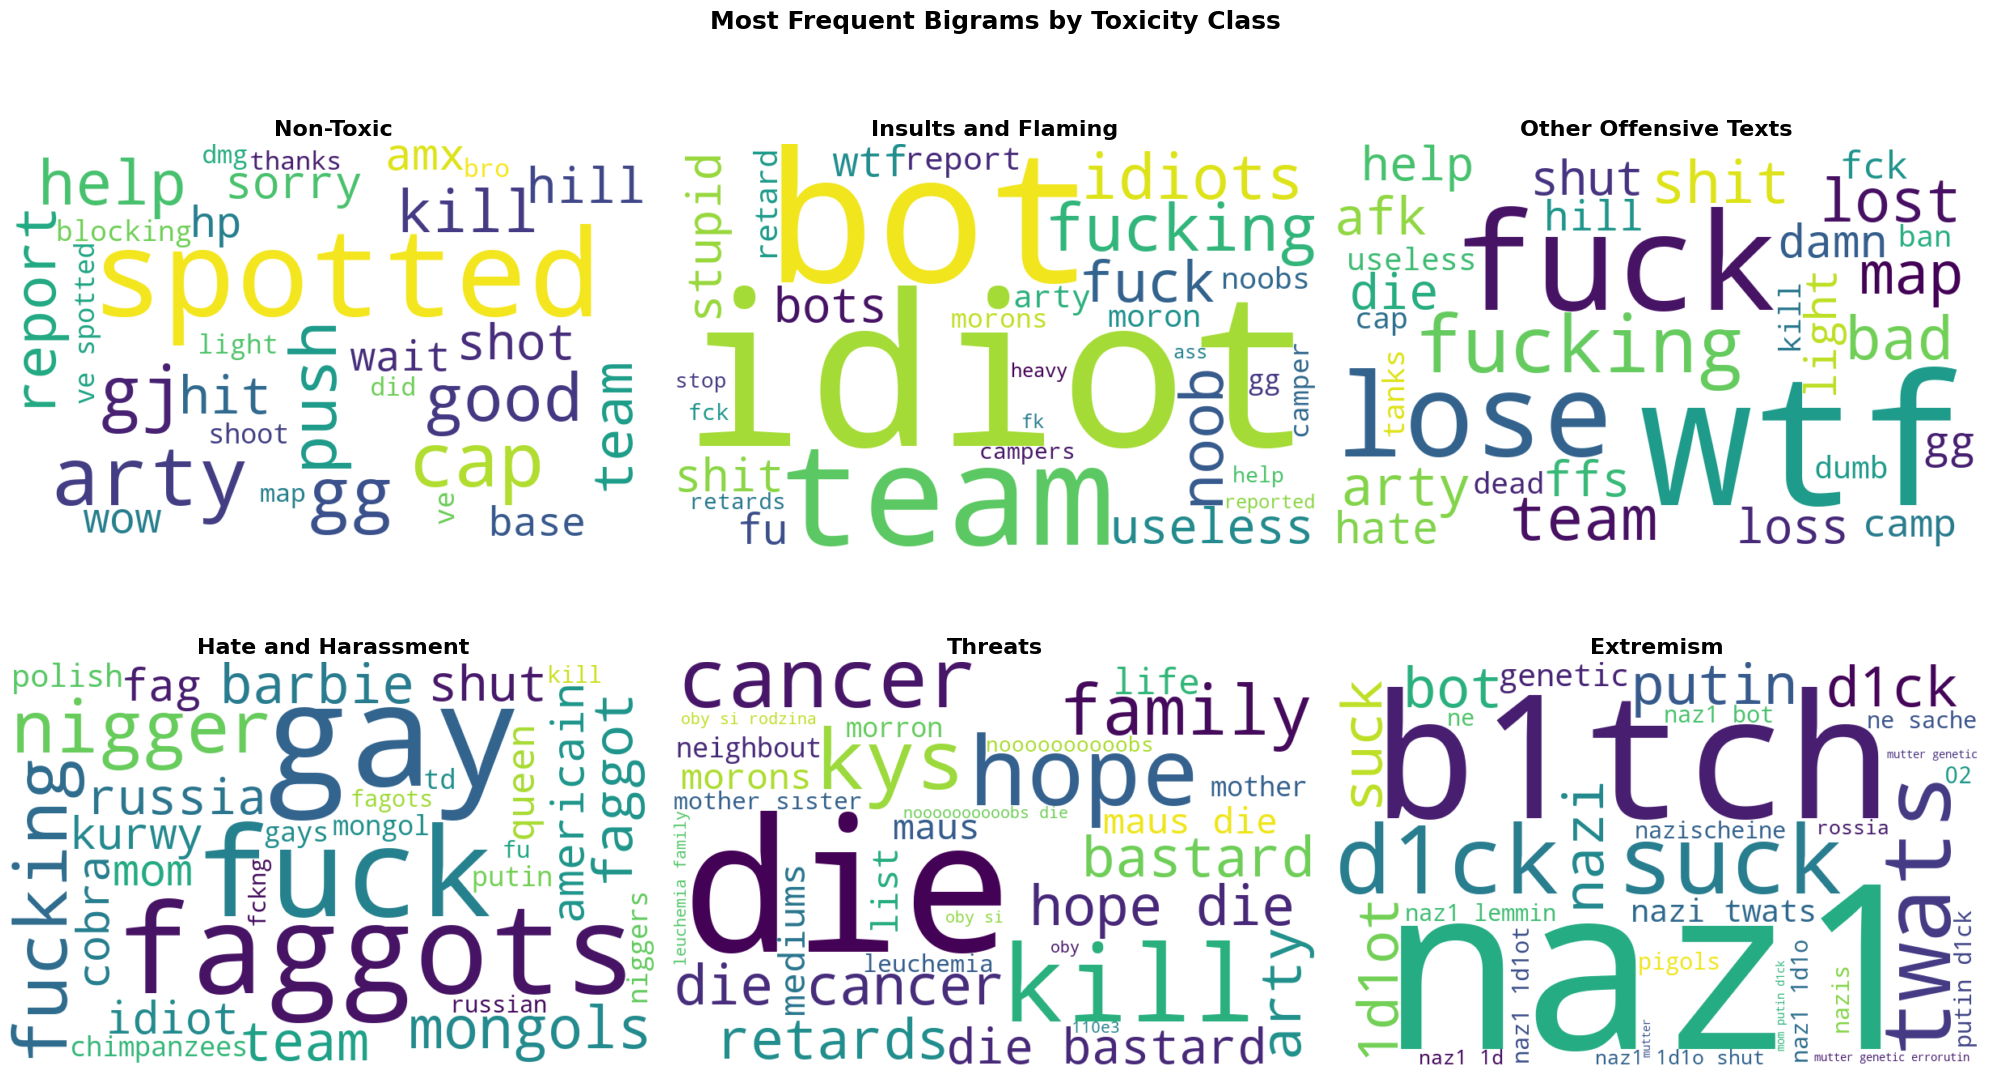

In [83]:
# class map
class_map = {
    0: "Non-Toxic",
    1: "Insults and Flaming",
    2: "Other Offensive Texts",
    3: "Hate and Harassment",
    4: "Threats",
    5: "Extremism"
}



# figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# create world clouds 
for i, cls in enumerate(sorted(train_df["label"].unique())):
    class_text = train_df.loc[train_df["label"] == cls, "message"].astype(str)
    
    # bigram vectorizer 
    bigram_vectorizer = CountVectorizer(
        # normalize accents
        strip_accents = "unicode", 
        # lowercase
        lowercase = True, 
        # stop words
        stop_words = list(STOPWORDS),
        max_df = 0.90,
        # ngram range
        ngram_range= (1, 3))
    
    
    # bigrams
    bigrams_trian = bigram_vectorizer.fit_transform(class_text)
    bigram_counts = bigrams_trian.sum(axis=0).A1
    bigram_names = bigram_vectorizer.get_feature_names_out()
    
    # bigrams frequency 
    bigram_freq_train = pd.DataFrame({
        "bigram": bigram_names,
        "count": bigram_counts
    }).sort_values(by="count", ascending=False).head(30)
    

    if len(bigram_freq_train) > 0:
        bigram_dict = dict(zip(bigram_freq_train["bigram"], 
                                bigram_freq_train["count"]))
        
        # worcloud 
        wordcloud = WordCloud(
            width=800,
            height=500,
            background_color="white"
        ).generate_from_frequencies(bigram_dict)
        
        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(class_map[cls], fontweight="bold", fontsize=16)
    else:
        axes[i].text(0.5, 0.5, "No bigrams found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")
        axes[i].set_title(class_map[cls], fontweight="bold", fontsize=16)

# design
plt.suptitle("Most Frequent Bigrams by Toxicity Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

The classes are well-separated. Non-Toxic is coordination language, Insults attack skill, Hate attacks identity, Threats wish harm, Extremism uses leetspeak evasion.

### Pre-processing

| Feature | TweetTokenizer | Standard (split / CountVectorizer default) |
|---|---|---|
| Handles `@mentions`, `#hashtags` | Keeps as single token | Splits on `#`, `@` |
| Repeated chars (`looool`, `!!!!!!`) | Collapses to max 3 (`loool`, `!!!`) | Keeps full noise |
| Emoticons (`:)`, `:(`) | Preserved as tokens | Broken or dropped |
| Gaming shorthand (`gg`, `wtf`, `xD`) | Preserved as-is | Usually fine but no special handling |
| All-caps preservation | Configurable (`preserve_case`) | Not supported |
| Punctuation inside words | Handles intelligently | Often splits incorrectly |
| Informal language | Designed for it | Designed for formal text |

**Bottom line:** Gaming chat is structurally identical to Twitter - short, informal, abbreviation-heavy, emoticon-rich. TweetTokenizer was built for exactly this domain.


In [84]:
# tokenizer
tokenizer = TweetTokenizer(reduce_len = True, 
                           strip_handles = True)

# tokenize and clean tokens 
def tokenize_full(text):
    # tokenize using tokenize twitter 
    tokens = tokenizer.tokenize(text)
    # preserve upper words like WOW and drop only if whole word not capitalized 
    tokens = [w + "_CAPS" if w.isupper() and len(w) > 1 else w.lower() for w in tokens]
    # drop stopwords 
    tokens = [w for w in tokens if w not in STOPWORDS]
    # drop punctuation
    tokens = [w for w in tokens if re.search(r"\w", w)]
    return tokens

In [85]:
# apply 
train_df["clean_tokens"] = train_df["message"].apply(tokenize_full)
validation_df["clean_tokens"] = validation_df["message"].apply(tokenize_full)

# check 
train_df["clean_tokens"].head(100)

0                    [spotted, F5_CAPS]
1                            [looseing]
2                              [player]
3     [idc, dammage, btw, comment, end]
4                          [maybe, fck]
                    ...                
95                          [ping, hit]
96                              [ateam]
97                              [awful]
98                               [epic]
99                             [e, 100]
Name: clean_tokens, Length: 100, dtype: object

All-caps words (`WTF`, `GG`, `NOOB`) carry expressive intensity in gaming - lowercasing them would lose that signal. Collapsing repeated punctuation reduces noise without removing the punctuation type itself.

#### Save Splits

In [86]:
# save splits to parquet 
train_df.to_parquet(PROJECT_ROOT / "data/processed_data/wot/wot_train_ml.parquet", index=False)
validation_df.to_parquet(PROJECT_ROOT / "data/processed_data/wot/wot_val_ml.parquet", index=False)


print("Saved:")
print(f"wot_train_ml.parquet - {train_df.shape}")
print(f"wot_val_ml.parquet - {validation_df.shape}")

Saved:
wot_train_ml.parquet - (38206, 4)
wot_val_ml.parquet - (4246, 3)


Three parquet files saved - one per split. 

## Dota 2 (CONDA)

In [87]:
# load Dota parquet
dota = pd.read_parquet(DATA_DIR_DOTA / "dota.parquet")
print(f"Dataset shape: {dota.shape}")
print(f"\nFirst 5 rows:\n{dota.head(5)}\n")
print(dota.info())

Dataset shape: (35682, 4)

First 5 rows:
   index  message  label  split
0  11263     wow!      0  train
1  13741      WTF      0  train
2  22125  wpe wpe      0  train
3   6453   hahaha      0  train
4   9644      wtf      0  train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35682 entries, 0 to 35681
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   index    35682 non-null  int64 
 1   message  35682 non-null  object
 2   label    35682 non-null  int64 
 3   split    35682 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.1+ MB
None


### Exploratory Data Analysis (EDA)

| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |

#### Duplicates

In [88]:
# all rows that appear more than once
dota_dup = dota[dota.duplicated(subset="message", keep=False)].sort_values("message")
dota_dup.head(10)

,index,message,label,split
26761,38158,!,0,train
17539,11136,!,0,train
28628,7592,!,0,val
9403,35992,!,0,train
10876,32061,!,0,train
19043,42692,!,0,train
23652,24950,!,0,train
33144,1008,!!,0,val
17554,6806,!!,0,train
14358,31944,!!!!,0,train


In [89]:
# top 30 most duplicated messages
dota_dup["message"].value_counts(ascending=False).head(30)

message
gg        1466
lol        691
?          445
ggwp       355
haha       348
gg wp      302
GG         290
ez         274
LOL        192
ty         160
:D         147
hahaha     135
wp         133
XD          96
GGWP        91
ok          82
EZ          81
+           78
Gg          74
:)          73
wtf         70
rofl        65
xD          60
wait        59
ez mid      59
HAHA        58
end         58
:(          55
g           55
)           54
Name: count, dtype: int64

In [90]:
# find messages with conflicting labels across annotators
conflicts = dota.groupby("message")["label"].nunique()
conflicts = conflicts[conflicts > 1]

print(f"Messages with conflicting labels: {len(conflicts)}")

conflict_rows = dota[dota["message"].isin(conflicts.index)].sort_values("message")
conflict_pct  = len(conflict_rows) / len(dota) * 100
print(f"Number of conflict rows: {len(conflict_rows)}")
print(f"Proportion of conflicting messages: {conflict_pct:.2f}%")

Messages with conflicting labels: 131
Number of conflict rows: 4715
Proportion of conflicting messages: 13.21%


Same as with world of tanks data set, we can not work with rows that have conflicting labels. 

In [91]:
# drop conflicting messages — annotation noise
dota = dota[~dota["message"].isin(conflicts.index)].reset_index(drop=True)
print(dota.shape)

(30967, 4)


In [92]:
# verify no conflicts remain
conflicts_after = dota.groupby("message")["label"].nunique()
conflicts_after = conflicts_after[conflicts_after > 1]
print(f"Conflicting messages remaining after removal: {len(conflicts_after)}")

Conflicting messages remaining after removal: 0


#### Class distribution

In [93]:
print(f"Class distribution:\n{dota['label'].value_counts()}\n")
print(f"Class distribution (normalized):\n{dota['label'].value_counts(normalize=True)}")

Class distribution:
label
0    22469
1     4650
2     2090
3     1758
Name: count, dtype: int64

Class distribution (normalized):
label
0    0.725579
1    0.150160
2    0.067491
3    0.056770
Name: proportion, dtype: float64


C:\Users\nyuss\AppData\Local\Temp\ipykernel_31400\937577134.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="label_name", data=dota, order=class_labels_dota, palette="colorblind", ax=axes[0])
C:\Users\nyuss\AppData\Local\Temp\ipykernel_31400\937577134.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_props.values, y=class_labels_dota, palette="colorblind", ax=axes[1])


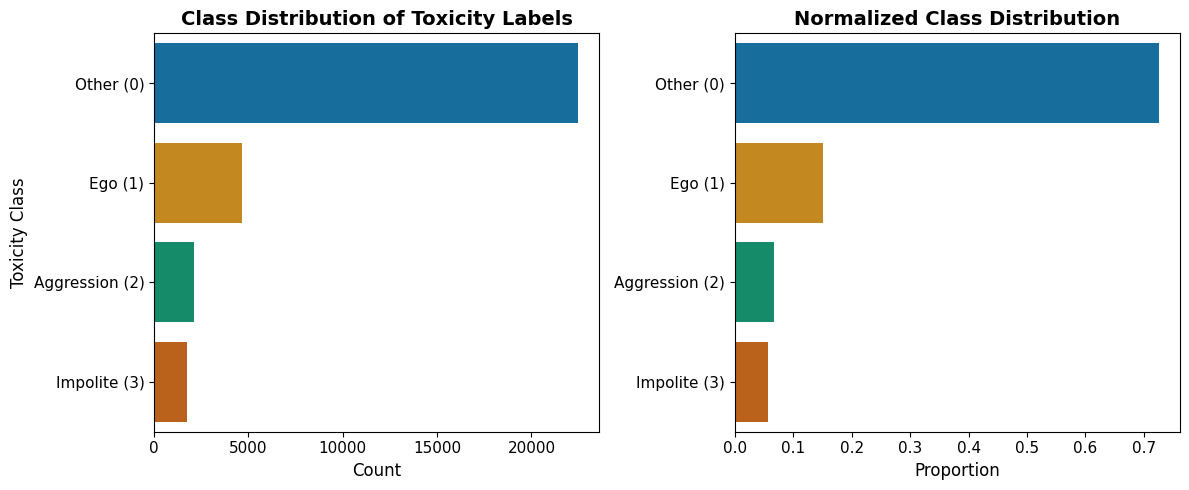

In [94]:
# distribution plot 
class_order_dota  = [0, 1, 2, 3]
class_labels_dota = ["Other (0)", "Ego (1)", "Aggression (2)", "Impolite (3)"]
label_map_dota    = dict(zip(class_order_dota, class_labels_dota))

dota["label_name"] = dota["label"].map(label_map_dota)

class_props = dota["label"].value_counts(normalize=True).reindex(class_order_dota)

# figure size 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# first plot
sns.countplot(y="label_name", data=dota, order=class_labels_dota, palette="colorblind", ax=axes[0])
axes[0].set_title("Class Distribution of Toxicity Labels", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Count", fontsize=12)
axes[0].set_ylabel("Toxicity Class", fontsize=12)
axes[0].tick_params(labelsize=11)

# second plot
sns.barplot(x=class_props.values, y=class_labels_dota, palette="colorblind", ax=axes[1])
axes[1].set_title("Normalized Class Distribution", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Proportion", fontsize=12)
axes[1].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

The distribution of classes in dota dataset is less imbalanced, but there is still imbalance. We again need to think about potential merging of classes, changing goal to binary classification or testing against multi-classification.

#### Non-English Messages (verification)

Dota 2 is a globally played game - non-ASCII messages are common. We drop them since we are building an English-only classifier.

In [95]:
# count non-ASCII messages
non_english_count = dota["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False).sum()
print(f"Number of non-English script messages: {non_english_count}")
print(f"Percentage: {(non_english_count / len(dota)) * 100:.2f}%")


Number of non-English script messages: 0
Percentage: 0.00%


Everything's clean.

#### Data Artifacts

In [96]:
# check for HTML entities
html_mask = dota["message"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Messages with HTML entities: {html_mask.sum()}")
dota[html_mask][["message", "label"]].head(10)

Messages with HTML entities: 0


,message,label


In [97]:
# decode HTML entities and check for any remaining
dota["message"] = dota["message"].apply(html_lib.unescape)

html_mask = dota["message"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Messages with HTML entities after decoding: {html_mask.sum()}")
print(f"Shape: {dota.shape}")

Messages with HTML entities after decoding: 0
Shape: (30967, 5)


In [98]:
# strip [SEPA] - it's a data collection artifact, not language
dota["message"] = dota["message"].str.replace(r"\s*\[SEPA\]\s*", " ", regex=True).str.strip()

# verify
sepa_remaining = dota["message"].str.contains(r"\[SEPA\]", regex=True, na=False).sum()
print(f"[SEPA] tokens remaining: {sepa_remaining}")

[SEPA] tokens remaining: 0


#### Word Frequency Analysis

In [99]:
# train/val split — stratified to preserve class proportions
X_dota = dota["message"]
y_dota = dota["label"]

X_dota_train, X_dota_val, y_dota_train, y_dota_val = train_test_split(
    X_dota, y_dota, test_size=0.10, random_state=seed, shuffle=True, stratify=y_dota
)

dota_train_df = pd.DataFrame({"message": X_dota_train, "label": y_dota_train}).reset_index(drop=True)
dota_val_df   = pd.DataFrame({"message": X_dota_val,   "label": y_dota_val}).reset_index(drop=True)

print(f"Train dataset shape: {dota_train_df.shape}")
print(f"Validation dataset shape: {dota_val_df.shape}")

Train dataset shape: (27870, 2)
Validation dataset shape: (3097, 2)


#### Number of words per document

In [100]:
# summary statistics of comment lengths
print("Summary statistics of comment lengths:")
dota_train_df["comment_length"] = dota_train_df["message"].str.split().str.len()
dota_train_df["comment_length"].describe()

Summary statistics of comment lengths:


count    27870.000000
mean         3.688841
std          3.343094
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         51.000000
Name: comment_length, dtype: float64

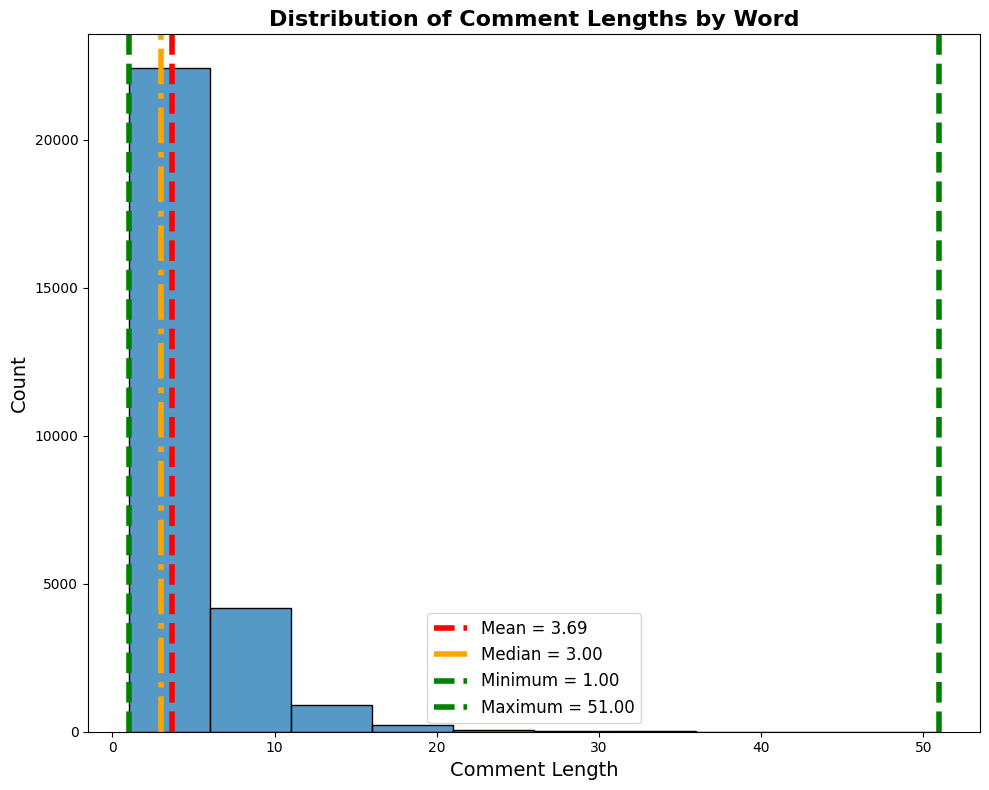

In [101]:
# distribution of comment lengths by word
mean_len   = dota_train_df["comment_length"].mean()
median_len = dota_train_df["comment_length"].median()
min_len    = dota_train_df["comment_length"].min()
max_len    = dota_train_df["comment_length"].max()

plt.figure(figsize=(10, 8))
sns.histplot(dota_train_df["comment_length"], bins=10, kde=False)

plt.axvline(mean_len,   linestyle="--", linewidth=4, label=f"Mean = {mean_len:.2f}",    color="red")
plt.axvline(median_len, linestyle="-.", linewidth=4, label=f"Median = {median_len:.2f}", color="orange")
plt.axvline(min_len,    linestyle="--", linewidth=4, label=f"Minimum = {min_len:.2f}",  color="green")
plt.axvline(max_len,    linestyle="--", linewidth=4, label=f"Maximum = {max_len:.2f}",  color="green")

plt.title("Distribution of Comment Lengths by Word", fontweight="bold", fontsize=16)
plt.xlabel("Comment Length", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Again, we can see than mean and median number of words in each message is ~3. We will utilize unigrams/bigrams for dota dataset as well.

In [102]:
# comments longer than or equal to the median top 10 words
dota_train_df[dota_train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
1,the wise fear my footfalls,5,0
2,ck got pretty much carried by cm,7,0
3,ez every lane really,4,3
4,fuck your mom,3,1
8,report for afk in fountain,5,0
10,KILL pLS TY,3,0
11,bad play sniper,3,1
12,im just here for emotional support,6,0
17,some out sf come out lkmao bher ownes ur ass,10,1
20,report everyone please ,4,3


In [103]:
# comments longer than or equal to the median bottom 10 words
dota_train_df[dota_train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
27853,es why not stun me,5,0
27860,omni you amke radi in 30 nin you can make much...,17,3
27861,SUP U FUCKA,3,1
27862,if only your 4k ember was 5k,7,3
27863,Nah that's the romans The greeks just have sta...,17,0
27864,ez mid :D ez gg,5,3
27865,oh ok is he return??,5,0
27866,he does i just don't get why these idiots don'...,20,1
27868,lol i ddint even realize i was still alive for...,13,0
27869,qop ditched you,3,0


In [104]:
# comments shorter than the median top 10 words
dota_train_df[dota_train_df["comment_length"] < median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
0,lmao,1,0
5,tele,1,0
6,pls wait,2,2
7,MGA ULOL,2,0
9,rc ?,2,0
13,:),1,0
14,GG WP,2,0
15,resdtart go,2,1
16,alche lol,2,0
18,hehe,1,0


In [105]:
# comments shorter than the median bottom 10 words
dota_train_df[dota_train_df["comment_length"] < median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
27849,haha,1,0
27850,map hack,2,0
27852,ez mid,2,3
27854,b?,1,0
27855,WP,1,0
27856,y,1,0
27857,crash,1,0
27858,storm blushes,2,0
27859,NO,1,0
27867,jajajaja,1,0


Messages are extremely short - median 3 words, max ~51 in train data. Dota 2 chat mirrors WoT: reaction-driven, not conversational. This confirms unigram + bigram TF-IDF is the right choice - trigrams would overfit to specific full messages rather than capturing reusable toxic patterns.

In [106]:
# top 20 most frequent words in training set
all_text = " ".join(X_dota_train.astype(str))
words = all_text.split()

word_freq = pd.DataFrame(Counter(words).items(), columns=["word", "count"])
word_freq = word_freq.sort_values(by="count", ascending=False)
word_freq.head(20)

,word,count
233,i,1418
80,u,1378
204,you,1211
75,gg,1062
115,is,900
196,a,829
82,me,812
1,the,809
317,to,795
13,ez,793


In [107]:
# stopwords dictionary 
EXTRA = {
    # contractions
    "u", "ur", "im", "ive", "youre", "dont", "doesnt", "cant",
    "wont", "isnt", "wasnt", "didnt", "wouldnt", "couldnt",
    "thats", "its", "hes", "shes", "theyre", "weve", "did",

    # pure filler
    "ok", "okay", "yeah", "yep", "nope", "nah",
    "oh", "ah", "uh", "um", "eh", "pls", "plz",
    "gonna", "gotta", "wanna", "tbh", "rly",
    "xd", "lol", "omg", "thx", "sry", "hf",

    # cross-class neutral bleed
    "just", "like", "time", "come", "win", "need",
    "xd", "guys", "lol", "omg", "thx", "rng",
    "play", "game", "tank", "spot",
    "today", "people", "kids", "nice", "sry", 

    # more fillers
    "yes", "gl", "try", "let", "stay", "got", "left", "line",
     "elc", "ebr", "wg", "wot", "tier", "doing", "loose",

    # Dota hero names only
    "abaddon", "alchemist", "axe", "bane", "batrider", "beastmaster",
    "bloodseeker", "brewmaster", "bristleback", "broodmother", "centaur",
    "chen", "clinkz", "clockwerk", "dazzle", "dawnbreaker", "disruptor",
    "doom", "enchantress", "enigma", "grimstroke", "gyrocopter", "hoodwink",
    "huskar", "invoker", "io", "jakiro", "juggernaut", "kunkka", "leshrac",
    "lich", "lifestealer", "lina", "lion", "luna", "lycan", "magnus",
    "marci", "mars", "medusa", "meepo", "mirana", "morphling", "muerta",
    "necrophos", "oracle", "pangolier", "phoenix", "puck", "pudge", "pugna",
    "razor", "riki", "rubick", "silencer", "slark", "slardar", "snapfire",
    "sniper", "spectre", "sven", "techies", "tidehunter", "timbersaw",
    "tinker", "tiny", "tusk", "underlord", "undying", "ursa", "viper",
    "visage", "warlock", "weaver", "zeus", "kez", "largo",

    # hero abbreviations
    "sf", "qop", "ta", "am", "es", "pa", "pl", "wk", "dk",
    "lc", "tb", "sk", "ns", "od", "wd", "sd", "ss", "kotl",
    "mk", "vs", "dp", "ck", "bh", "sb", "ember", "void", "storm",
    "jugg", "jug", "drow", "bara", "gyro", "legion", "rosh", "clock",
    "necro", "invo", "potm",

    # game mechanics with zero signal
    "ggwp", "mmr", "ff", "dc", "w8", "rc",
    "reconnecting", "reconnect", "lag",
    "just", "like", "really", "guys", "know", "come",
    "want", "time", "got", "win", "play", "game",
    "end", "nice", "good", "wait", "pro", "wow",
    "haha", "rofl", "ty", "thanks", "said", "min",
    "sec", "wr", "need", "team", "afk", }

# append with sklearn dictionary
STOPWORDS = ENGLISH_STOP_WORDS.union(EXTRA)  # frozenset, O(1) lookup
print(STOPWORDS)

frozenset({'itself', 'six', 'afk', 'back', 'an', 'herself', 'others', 'most', 'perhaps', 'mars', 'whenever', 'meanwhile', 'batrider', 'brewmaster', 'tidehunter', 'vs', 'do', 'four', 'doom', 'phoenix', 'please', 'few', 'thx', 'whose', 'need', 'amount', 'oh', 'less', 'sincere', 'may', 'side', 'thereafter', 'either', 'among', 'oracle', 'pugna', 'pudge', 'eh', 'their', 'clock', 'never', 'too', 'again', 'two', 'he', 'today', 'hasnt', 'ours', 'keep', 'else', 'with', 'done', 'broodmother', 'however', 'sry', 'this', 'kunkka', 'last', 'nah', 'seem', 'did', 'these', 'amongst', 'gl', 'dawnbreaker', 'they', 'tier', 'neither', 'afterwards', 'put', 'next', 'our', 'really', 'himself', 'necro', 'via', 'legion', 'up', 'at', 'even', 'wanna', 'weaver', 'largo', 'was', 'own', 'made', 'silencer', 'where', 'because', 'why', 'plz', 'also', 'my', 'ur', 'hes', 'lifestealer', 'theyre', 'until', 'anywhere', 'people', 'down', 'magnus', 'win', 'underlord', 'must', 'whereafter', 'disruptor', 'axe', 'wont', 'marci',

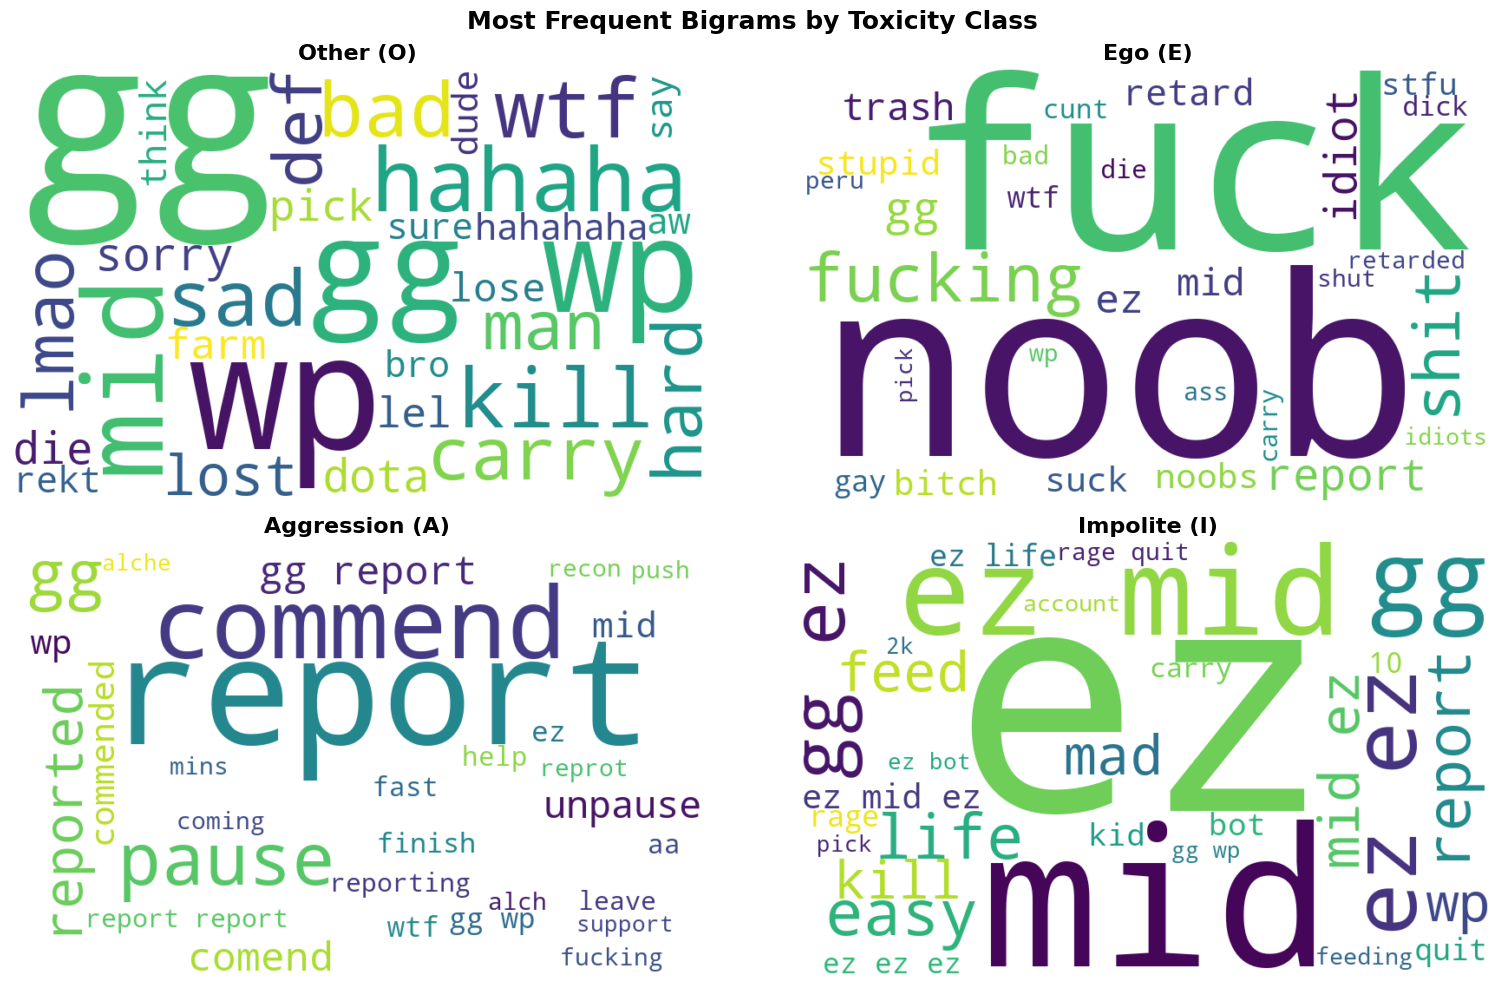

In [108]:
class_map_dota = {0: "Other (O)", 1: "Ego (E)", 2: "Aggression (A)", 3: "Impolite (I)"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(sorted(dota_train_df["label"].unique())):
    class_text = dota_train_df.loc[dota_train_df["label"] == cls, "message"].astype(str)

    bigram_vectorizer = CountVectorizer(
        strip_accents="unicode",
        lowercase=True,
        stop_words=list(STOPWORDS),
        max_df=0.90,
        ngram_range=(1, 3)
    )

    bigrams_train = bigram_vectorizer.fit_transform(class_text)
    bigram_counts = bigrams_train.sum(axis=0).A1
    bigram_names  = bigram_vectorizer.get_feature_names_out()

    bigram_freq_train = pd.DataFrame({
        "bigram": bigram_names,
        "count":  bigram_counts
    }).sort_values(by="count", ascending=False).head(30)

    if len(bigram_freq_train) > 0:
        bigram_dict = dict(zip(bigram_freq_train["bigram"], bigram_freq_train["count"]))
        wordcloud = WordCloud(width=800, height=500, background_color="white").generate_from_frequencies(bigram_dict)
        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(class_map_dota[cls], fontweight="bold", fontsize=16)
    else:
        axes[i].text(0.5, 0.5, "No bigrams found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")
        axes[i].set_title(class_map_dota[cls], fontweight="bold", fontsize=16)

plt.suptitle("Most Frequent Bigrams by Toxicity Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

The classes are well-separated. Other (non-toxic) uses coordination language (gg, wp, nice). Ego centers on boasting and blame directed at teammates. Aggression uses direct insults and profanity. Impolite uses mild rudeness without explicit slurs - the most ambiguous class and hardest to distinguish from Ego.

- **Signals:**
    - Other (O): gg, wp, kill, carry, hard, bad, wtf - neutral game outcomes + sportsmanship

    - Ego (E): noob, fuck, fucking, shit, idiot, retard - skill attacks

    - Aggression (A): report, reported, reporting - behavior complaints dominate clearly

    - Impolite (I): ez, mid, easy, bot, life, kid, rage - condescension

### Pre-processing

Same TweetTokenizer pipeline as WoT - Dota 2 chat is structurally identical: short, informal, abbreviation-heavy. All-caps words (`REPORT`, `GG`) preserved for expressive intensity.

In [109]:
# apply same cleaner used for WoT
dota_train_df["clean_tokens"] = dota_train_df["message"].apply(tokenize_full)
dota_val_df["clean_tokens"] = dota_val_df["message"].apply(tokenize_full)

print("Sample cleaned messages:")
dota_train_df["clean_tokens"]

Sample cleaned messages:


0                                                   [lmao]
1                                  [wise, fear, footfalls]
2                                    [pretty, carried, cm]
3                                               [ez, lane]
4                                              [fuck, mom]
                               ...                        
27865                                             [return]
27866    [does, don't, idiots, don't, listen, tell, hi,...
27867                                           [jajajaja]
27868                     [ddint, realize, alive, 2, secs]
27869                                            [ditched]
Name: clean_tokens, Length: 27870, dtype: object

#### Save Splits

In [110]:
# save splits to parquet
dota_train_df.to_parquet(DATA_DIR_DOTA / "dota_train_ml.parquet", index=False)
dota_val_df.to_parquet(DATA_DIR_DOTA / "dota_val_ml.parquet", index=False)

print("Saved:")
print(f"dota_train_ml.parquet — {dota_train_df.shape}")
print(f"dota_val_ml.parquet  — {dota_val_df.shape}")

Saved:
dota_train_ml.parquet — (27870, 4)
dota_val_ml.parquet  — (3097, 3)
